# 1 - Exploring the credit card transactions

The dataset is the ULB / Worldline *Credit Card Fraud Detection* set: two days of
European card transactions from September 2013, with the original features replaced
by 28 PCA components for confidentiality. Only `Time`, `Amount` and the fraud label
survive in their original form.

The point of this notebook is to establish the three facts that shape every modelling
decision later: how rare fraud is, what `Amount` and `Time` actually look like, and
which of the PCA components carry any signal at all.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
from dq_anomaly.data.loaders import load_creditcard

df = load_creditcard()
print(f"{len(df):,} transactions, {df.shape[1]} columns")
print(f"Missing values: {int(df.isna().sum().sum())}")
df.head(3)

284,807 transactions, 31 columns
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## How rare is fraud?

This single number drives everything: the choice of metric, the alert budget, and why
accuracy is a meaningless target here.

In [3]:
counts = df["Class"].value_counts()
prevalence = df["Class"].mean()
print(counts.to_string())
print(f"\nFraud prevalence: {prevalence:.4%} (1 in {1/prevalence:,.0f} transactions)")
print(f"A model that always predicts 'legitimate' would be {1 - prevalence:.4%} accurate")
print("and would catch nothing at all. Accuracy is not a usable target here.")

Class
0    284315
1       492

Fraud prevalence: 0.1727% (1 in 579 transactions)
A model that always predicts 'legitimate' would be 99.8273% accurate
and would catch nothing at all. Accuracy is not a usable target here.


## Amount and time

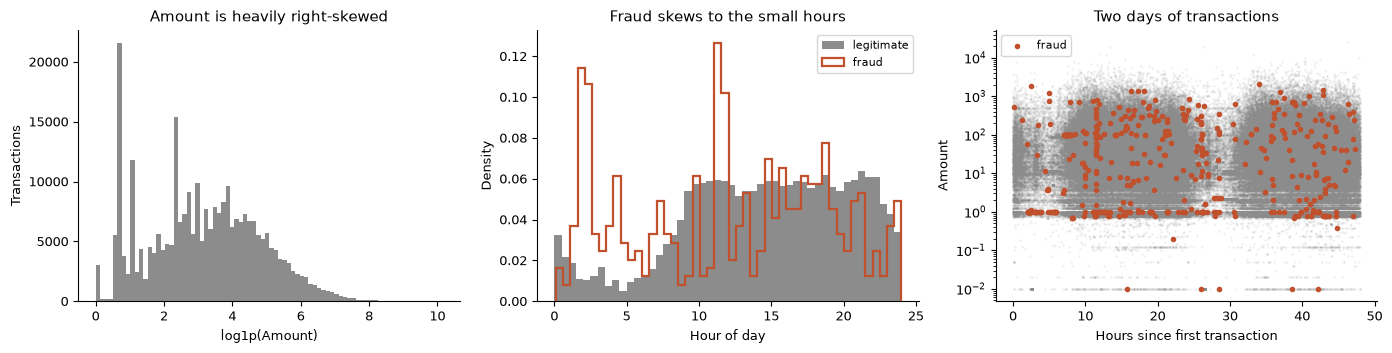

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].hist(np.log1p(df["Amount"]), bins=80, color="#8c8c8c")
axes[0].set(xlabel="log1p(Amount)", ylabel="Transactions", title="Amount is heavily right-skewed")

hours = (df["Time"] / 3600) % 24
axes[1].hist(hours[df["Class"] == 0], bins=48, density=True, color="#8c8c8c", label="legitimate")
axes[1].hist(hours[df["Class"] == 1], bins=48, density=True, histtype="step",
             color="#c1512d", linewidth=1.6, label="fraud")
axes[1].set(xlabel="Hour of day", ylabel="Density", title="Fraud skews to the small hours")
axes[1].legend(fontsize=8)

axes[2].scatter(df.loc[df["Class"] == 0, "Time"] / 3600,
                df.loc[df["Class"] == 0, "Amount"], s=1, alpha=0.08, color="#8c8c8c")
axes[2].scatter(df.loc[df["Class"] == 1, "Time"] / 3600,
                df.loc[df["Class"] == 1, "Amount"], s=9, color="#c1512d", label="fraud")
axes[2].set(xlabel="Hours since first transaction", ylabel="Amount",
            title="Two days of transactions", yscale="log")
axes[2].legend(fontsize=8)
plt.tight_layout()

In [5]:
print(df.groupby("Class")["Amount"].describe()[["count", "mean", "50%", "max"]].to_string())
print()
print("Fraudulent transactions are smaller on average, which is consistent with")
print("card testing: attackers verify a stolen card with a low-value purchase first.")

          count        mean    50%       max
Class                                       
0      284315.0   88.291022  22.00  25691.16
1         492.0  122.211321   9.25   2125.87

Fraudulent transactions are smaller on average, which is consistent with
card testing: attackers verify a stolen card with a low-value purchase first.


`Time` is seconds elapsed since the first transaction in the file. That makes it a
monotone row index, not a reusable feature: a future batch would start again from zero.
What *is* reusable is the hour of day, and the middle panel above shows it carries real
signal. It is encoded as sine and cosine in the pipeline so that 23:59 and 00:01 sit
next to each other.

## Which PCA components separate the classes?

Most separating: V17, V14, V12, V10, V16, V3
Least separating: V15, V25, V23, V22


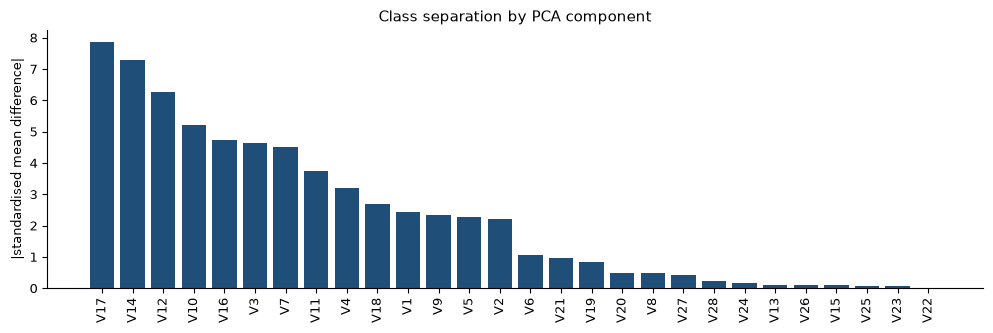

In [6]:
v_cols = [f"V{i}" for i in range(1, 29)]
separation = (
    (df.loc[df["Class"] == 1, v_cols].mean() - df.loc[df["Class"] == 0, v_cols].mean())
    / df[v_cols].std()
).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(separation.index, separation.values, color="#1f4e79")
ax.set(ylabel="|standardised mean difference|",
       title="Class separation by PCA component")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()

print("Most separating:", ", ".join(separation.head(6).index))
print("Least separating:", ", ".join(separation.tail(4).index))

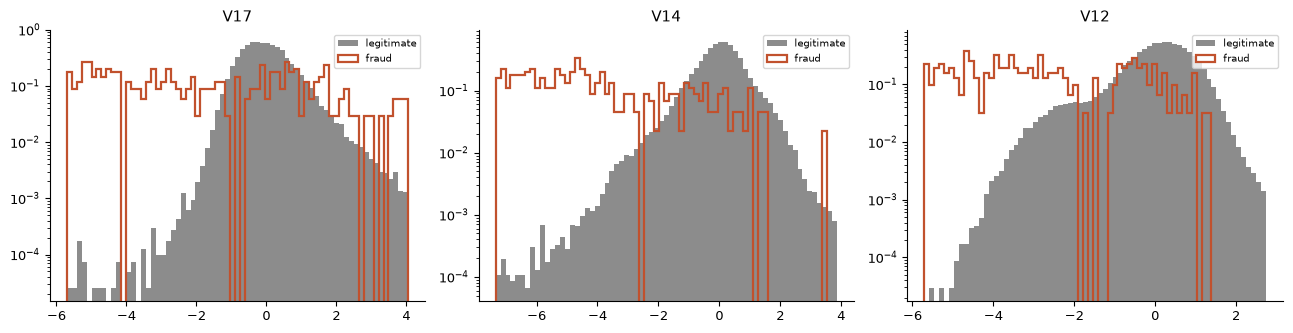

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, separation.head(3).index):
    bins = np.linspace(df[col].quantile(0.001), df[col].quantile(0.999), 70)
    ax.hist(df.loc[df["Class"] == 0, col], bins=bins, density=True, color="#8c8c8c",
            label="legitimate")
    ax.hist(df.loc[df["Class"] == 1, col], bins=bins, density=True, histtype="step",
            color="#c1512d", linewidth=1.6, label="fraud")
    ax.set(title=col, yscale="log")
    ax.legend(fontsize=7)
plt.tight_layout()

## What this means for the model

A handful of components separate the classes cleanly, which is why a supervised model
does very well on this dataset. But the premise of a data quality gate is that labels
are *not* available: nobody has told us which purchase order lines or journal entries
are wrong. So the models that follow are trained without labels, and the supervised
result is kept only as a ceiling to measure against.

The standard deviations of the components also differ by a factor of six, which is why
the feature matrix is standardised before it reaches the autoencoder: an unscaled MSE
loss would be dominated by the high-variance components and would effectively ignore
the rest.

In [8]:
print(df[v_cols].std().describe()[["min", "50%", "max"]].to_string())

min    0.330083
50%    0.936956
max    1.958696
